In [1]:
!pip install cartopy # Esta línea es para instalar cartopy. En su PC sólo tendría que hacerlo una vez, con algo como "conda install -c conda-forge cartopy"
import cartopy.crs as ccrs
import cartopy.feature

In [2]:
#Cargamos las librerías
import numpy as np #Librería para operaciones numéricas
import matplotlib.pyplot as plt #Librería para generar gráficas

import xarray as xr #librería para el manejo de archivos NetCDF

# Y otras herramientas:
import os
import datetime
import pandas as pd


In [3]:
#Cargar y abrir  NetCDF
ifile = xr.open_dataset('era5land_geopotential-sfc.nc') # Se carga el archivo NetCDF
ifile # llamamos otra vez a ifile, para ver un resumen de lo que contiene

<xarray.Dataset> Size: 52MB
Dimensions:    (time: 1, latitude: 1801, longitude: 3600)
Coordinates:
  * time       (time) datetime64[ns] 8B 2013-08-09T12:00:00
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
Data variables:
    z          (time, latitude, longitude) float64 52MB ...
Attributes:
    Conventions:               CF-1.6
    history:                   Fri Jun 12 14:41:56 2020: ncpdq -U geo_1279l4_...
    NCO:                       4.7.2
    nco_openmp_thread_number:  1

In [4]:
# Con base en la información anterior, seleccionamos parte de los datos:
zm = (ifile.z)/9.8 #Del archivo tomamos los datos la variable "z" y se convierten a altura en metros
lat_t2m = ifile.latitude #tomamos los datos de la variable latitud
lon_t2m = ifile.longitude #tomamos los datos de la variable longitud


In [5]:
zm

<xarray.DataArray 'z' (time: 1, latitude: 1801, longitude: 3600)> Size: 52MB
array([[[ 1.46253971e-01,  1.46253971e-01,  1.46253971e-01, ...,
          1.46253971e-01,  1.46253971e-01,  1.46253971e-01],
        [ 1.46253971e-01,  1.46253971e-01,  1.46253971e-01, ...,
          1.46253971e-01,  1.46253971e-01,  1.46253971e-01],
        [-4.68746977e-01, -4.68746977e-01, -4.68746977e-01, ...,
         -4.68746977e-01, -4.68746977e-01, -4.68746977e-01],
        ...,
        [ 2.77462053e+03,  2.77482553e+03,  2.77482553e+03, ...,
          2.77441553e+03,  2.77462053e+03,  2.77462053e+03],
        [ 2.77626053e+03,  2.77626053e+03,  2.77646553e+03, ...,
          2.77626053e+03,  2.77626053e+03,  2.77626053e+03],
        [ 2.76683052e+03,  2.76683052e+03,  2.76683052e+03, ...,
          2.76683052e+03,  2.76683052e+03,  2.76683052e+03]]])
Coordinates:
  * time       (time) datetime64[ns] 8B 2013-08-09T12:00:00
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
Attributes:
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential

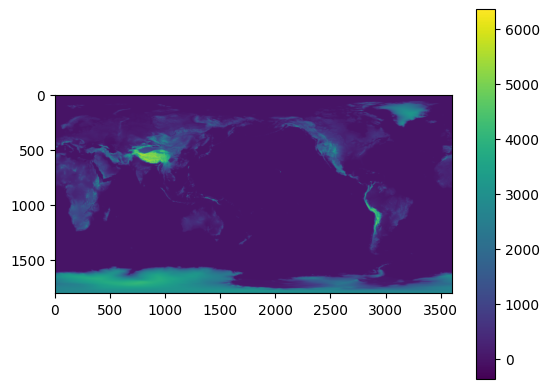

In [6]:
# Pasamos por una forma muy simplista de graficar,
# solo para verificar si los datos tienen sentido:
plt.imshow(zm[0, :, :])
plt.colorbar()  # Adds a color reference bar
plt.show()

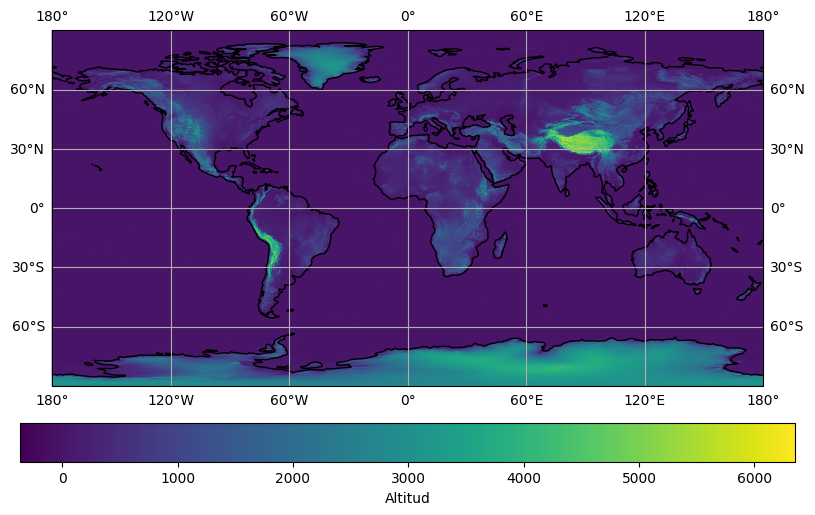

In [7]:
# Ahora graficamos todo el campo, usando pcolormesh (en lugar de contourf)

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Graficar, usando las coordenadas espaciales
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm[0, :, :], transform=ccrs.PlateCarree(), cmap="viridis"
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="horizontal", label="Altitud", pad=0.08)
plt.show()

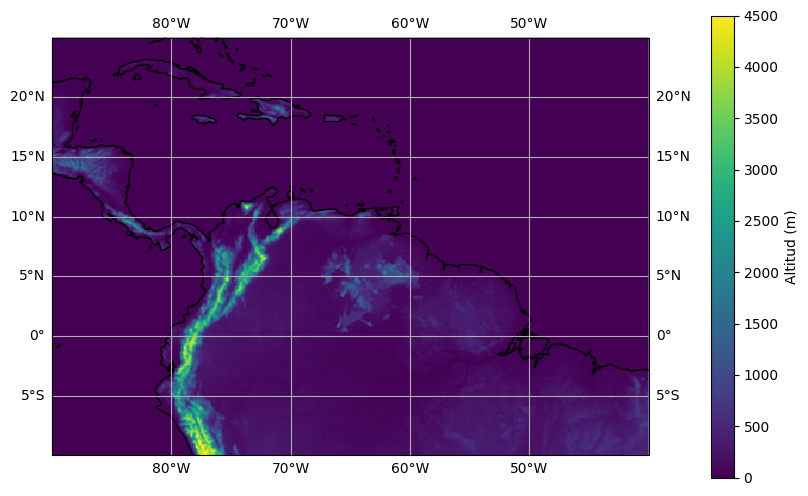

In [8]:
# Ahora, graficamos para una región limitada:

# Definir region: [lon_min, lon_max, lat_min, lat_max]
extent = [-90, -40, -10, 25]  #

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Restringir la región de interés en la figura
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Graficar, usando las coordenadas espaciales
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm[0, :, :], transform=ccrs.PlateCarree(), cmap="viridis", vmin=0, vmax=4500
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="vertical", label="Altitud (m)", pad=0.08)
plt.show()

In [9]:
# Podemos ver de la figura anterior, que se ponen colores (valores) sobre el mar.
# En muchos casos es útil tener información sólo sobre el continente.

# Para tal fin, es útil usar una máscara tierra-mar, o land-sea mask.
# En general, una máscara permite seleccionar o resaltar sólo una región de interés,
# poniendo ceros (0.0) o valores perdidos (e.g. NaNs) fuera de dicha región.

# En el caso de ERA5-Land, tenemos la variable land-sea mask para este propósito.

In [10]:
#Cargar y abrir  NetCDF
ifl2 = xr.open_dataset('era5land_landsea-mask.nc') # Se carga el archivo NetCDF
ifl2 # llamamos otra vez a ifile, para ver un resumen de lo que contiene

<xarray.Dataset> Size: 52MB
Dimensions:    (time: 1, latitude: 1801, longitude: 3600)
Coordinates:
  * time       (time) datetime64[ns] 8B 2013-11-29
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
Data variables:
    lsm        (time, latitude, longitude) float64 52MB ...
Attributes:
    Conventions:               CF-1.6
    history:                   Fri Jun 12 14:44:03 2020: ncpdq -U lsm_1279l4_...
    NCO:                       4.7.2
    nco_openmp_thread_number:  1

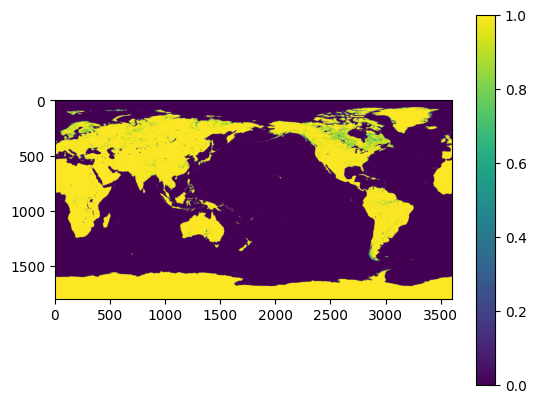

In [11]:
# Pasamos por una forma muy simplista de graficar,
# solo para verificar si los datos tienen sentido:
plt.imshow(ifl2.lsm[0, :, :])
plt.colorbar()  # Adds a color reference bar
plt.show()

In [12]:
# Para multiplicar un campo por la máscara, se puede hacer:

# Extraer los arreglos
zm_2d = zm[0, :, :]
lsm_2d = ifl2.lsm[0, :, :]

# Multiplicar elemento a elemento (celda a celda)
zm_masked = zm_2d * lsm_2d
zm_masked # Imprimir su descripción. Compare con la descripción de zm.

<xarray.DataArray (latitude: 1801, longitude: 3600)> Size: 52MB
array([[   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [  -0.        ,   -0.        ,   -0.        , ...,   -0.        ,
          -0.        ,   -0.        ],
       ...,
       [2774.62053192, 2774.82553224, 2774.82553224, ..., 2774.41553161,
        2774.62053192, 2774.62053192],
       [2776.26053445, 2776.26053445, 2776.46553477, ..., 2776.26053445,
        2776.26053445, 2776.26053445],
       [2766.83051991, 2766.83051991, 2766.83051991, ..., 2766.83051991,
        2766.83051991, 2766.83051991]])
Coordinates:
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9

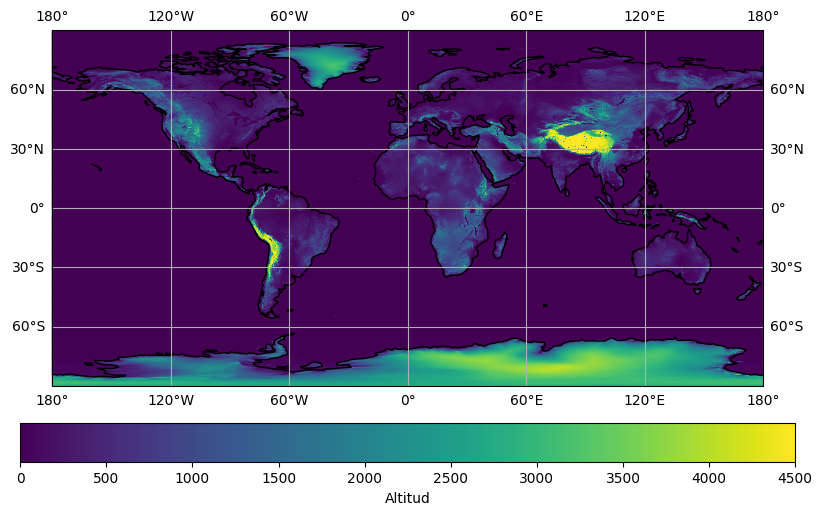

In [13]:
# Ahora graficamos todo el campo, usando pcolormesh (en lugar de contourf)

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Graficar, usando las coordenadas espaciales
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm_masked[:, :], transform=ccrs.PlateCarree(), cmap="viridis", vmin=0, vmax=4500
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="horizontal", label="Altitud", pad=0.08)
plt.show()

In [14]:
# Finalmente, reemplazamos los valores diferentes de 0 con NaN
zm_masked = zm_masked.where(zm_masked != 0)
zm_masked # comparar con zm y con zm_masked más arriba

<xarray.DataArray (latitude: 1801, longitude: 3600)> Size: 52MB
array([[          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       ...,
       [2774.62053192, 2774.82553224, 2774.82553224, ..., 2774.41553161,
        2774.62053192, 2774.62053192],
       [2776.26053445, 2776.26053445, 2776.46553477, ..., 2776.26053445,
        2776.26053445, 2776.26053445],
       [2766.83051991, 2766.83051991, 2766.83051991, ..., 2766.83051991,
        2766.83051991, 2766.83051991]])
Coordinates:
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9

In [16]:
# Si en el paso anterior zm_masked tiene ahora tres dimensiones, seleccione solo las espaciales:
zm_masked = zm_masked[:,:]
zm_masked

<xarray.DataArray (latitude: 1801, longitude: 3600)> Size: 52MB
array([[          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       ...,
       [2774.62053192, 2774.82553224, 2774.82553224, ..., 2774.41553161,
        2774.62053192, 2774.62053192],
       [2776.26053445, 2776.26053445, 2776.46553477, ..., 2776.26053445,
        2776.26053445, 2776.26053445],
       [2766.83051991, 2766.83051991, 2766.83051991, ..., 2766.83051991,
        2766.83051991, 2766.83051991]])
Coordinates:
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9

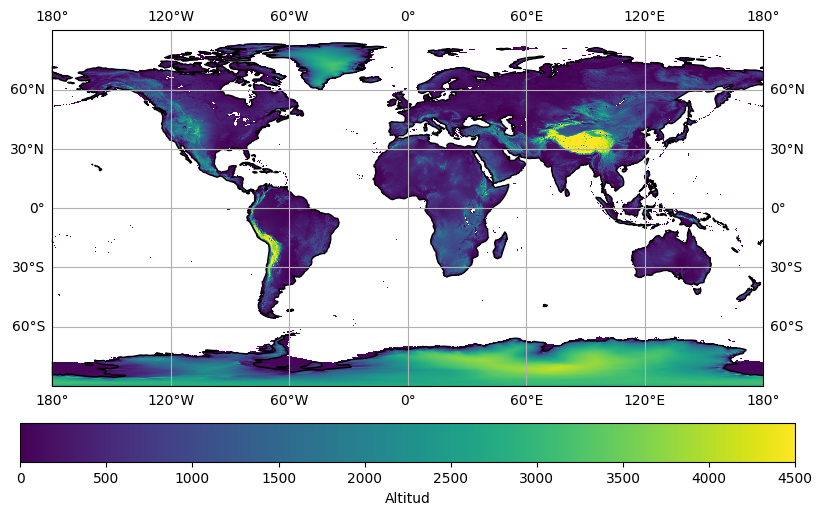

In [17]:
# Ahora graficamos todo el campo, usando pcolormesh (en lugar de contourf)

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Graficar, usando las coordenadas espaciales
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm_masked[:, :], transform=ccrs.PlateCarree(), cmap="viridis", vmin=0, vmax=4500
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="horizontal", label="Altitud", pad=0.08)
plt.show()

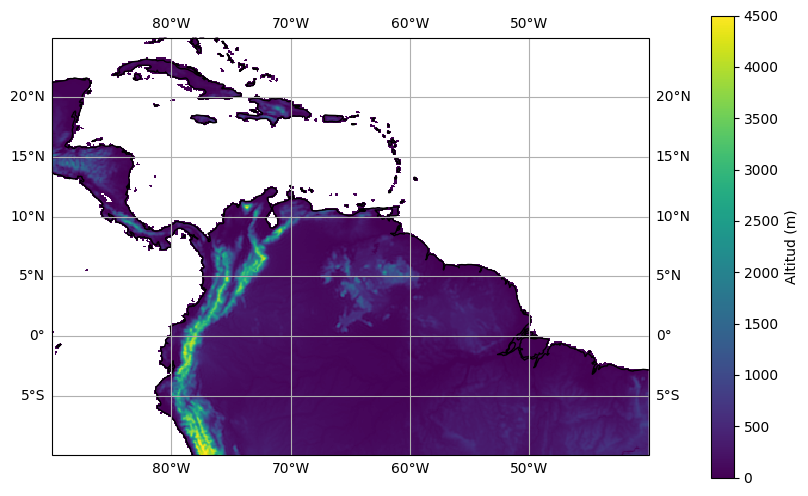

In [18]:
# Ahora, graficamos para una región limitada:

# Definir region: [lon_min, lon_max, lat_min, lat_max]
extent = [-90, -40, -10, 25]  #

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Restringir la región de interés en la figura
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Graficar, usando las coordenadas espaciales
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm_masked[:, :], transform=ccrs.PlateCarree(), cmap="viridis", vmin=0, vmax=4500
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="vertical", label="Altitud (m)", pad=0.08)
plt.show()

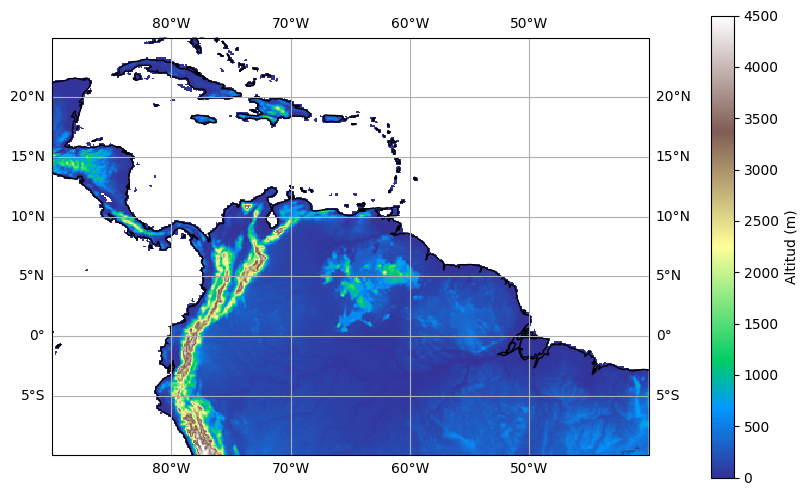

In [19]:
# Es posible usar otra barra de colores, más apropiada para la topografía

# Ahora, graficamos para una región limitada:

# Definir region: [lon_min, lon_max, lat_min, lat_max]
extent = [-90, -40, -10, 25]  #

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Restringir la región de interés en la figura
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Graficar, usando las coordenadas espaciales.
# Colormaps: "terrain", "gist_earth"
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm_masked[:, :], transform=ccrs.PlateCarree(), cmap="terrain", vmin=0, vmax=4500
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="vertical", label="Altitud (m)", pad=0.08)
plt.show()

In [20]:
# Acá vamos a cargar un shapefile, que usaremos luego para graficar el mapa

# En este ejemplo, usamos datos de Antioquia:
#https://open-data-gobantioquia.hub.arcgis.com/datasets/municipios-/explore?location=7.146710%2C-75.508170%2C7

# Agregar shape-file con municipios:
from cartopy.feature import ShapelyFeature
from shapely.geometry import Polygon
# Definir la ruta al shapefile (cargado en Colab, o ruta completa en local)
shapefile_path = 'municipios_.shp'
# Leer con geopandas, que es más robusto
!pip install geopandas # Instalar, si es necesario.
import geopandas as gpd
# Leer el shapefile
municipios_gdf = gpd.read_file(shapefile_path)


# --- Debugging: Verificar que el shapefile tenga contenido ---
print(f"Is municipios_gdf empty? {municipios_gdf.empty}")
if not municipios_gdf.empty:
    print(f"Bounds of municipios_gdf: {municipios_gdf.total_bounds}")
else:
    print("municipios_gdf is empty, no features to plot.")
# -----------------------------------------------------

# Leer el Coordinate Reference System (CRS) del shapefile
print(f"Shapefile CRS: {municipios_gdf.crs}")

# --- Reproyectar el shapefile a WGS84 (latitude/longitude) ---
# Verificar si el CRS ya es lat-lon (EPSG:4326 or similar)
if municipios_gdf.crs != 'EPSG:4326':
    print(f"Reproyectando shapefile de {municipios_gdf.crs} a EPSG:4326 (WGS84).")
    municipios_gdf = municipios_gdf.to_crs(epsg=4326)
else:
    print("Shapefile ya está en EPSG:4326.")
# --------------------------------------------------------------

# Ver las coordenadas de la región del shapefile
# Los límites son (min_x, min_y, max_x, max_y)
minx, miny, maxx, maxy = municipios_gdf.total_bounds
print(f"\nLímites son (min_lon, min_lat, max_lon, max_lat): {minx, miny, maxx, maxy}")

Is municipios_gdf empty? False
Bounds of municipios_gdf: [-8585831.   604092. -8224427.   991819.]
Shapefile CRS: EPSG:3857
Reproyectando shapefile de EPSG:3857 a EPSG:4326 (WGS84).

Límites son (min_lon, min_lat, max_lon, max_lat): (np.float64(-77.12783214167195), np.float64(5.418555584769559), np.float64(-73.88128477225263), np.float64(8.873969565336159))


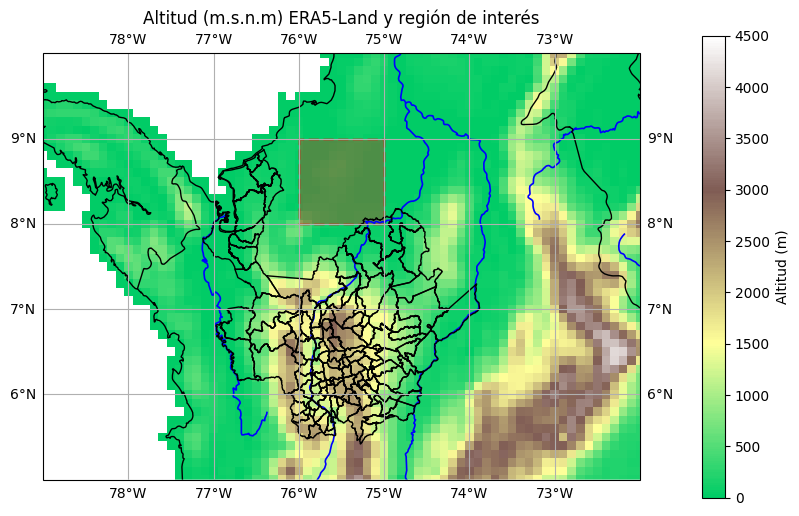

In [21]:
# Finalmente, graficamos con algunas opciones más: identifique las diferencias.

# Truncar 'terrain' para skip el 25% azul, y empezar en verde
import matplotlib.colors as mcolors
orig_cmap = plt.get_cmap("terrain")
colors = orig_cmap(np.linspace(0.25, 1.0, 256))
terrain_no_blue = mcolors.LinearSegmentedColormap.from_list(
    "terrain_no_blue", colors
)

# Ahora, graficamos para una región limitada:

# Definir region: [lon_min, lon_max, lat_min, lat_max]
extent = [-79, -72, 5, 10]  #

# Inicializar la figura con la PlateCarree map projection
fig, ax = plt.subplots(
    figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Restringir la región de interés en la figura
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Graficar, usando las coordenadas espaciales.
# Colormaps: "terrain", "gist_earth"
mesh = ax.pcolormesh(
    lon_t2m, lat_t2m, zm_masked[:, :], transform=ccrs.PlateCarree(), cmap=terrain_no_blue, vmin=0, vmax=4500
)

# Agregar líneas de costa, y un grid.
ax.coastlines()
ax.gridlines(draw_labels=True)

# Agregar rios
import cartopy.feature as cfeature
ax.add_feature(
    cfeature.RIVERS.with_scale("10m"), edgecolor="blue", linewidth=1.2
)

# Agregar bordes políticos
ax.add_feature(cartopy.feature.BORDERS) #Se agregan los países


# Add the shapefile feature
# Definir el atributo para cartopy
municipios_feature = ShapelyFeature(municipios_gdf.geometry, ccrs.PlateCarree(),
                                    edgecolor='black', facecolor='none', linewidth=1.0)
ax.add_feature(municipios_feature)

# Agregar un rectángulo, para señalar una región de interés:
# Definir las coordenadas
import matplotlib.patches as mpatches
lon_min, lon_max = -76, -75
lat_min, lat_max = 8, 9
# (xy = coordenadas del sur-oeste)
rect = mpatches.Rectangle(
    xy=(lon_min, lat_min),
    width=lon_max - lon_min,
    height=lat_max - lat_min,
    facecolor="red",  # Fill color (use 'none' for border only)
    alpha=0.3,  # Transparencia del rectángulo (0 to 1)
    edgecolor="red",  # Color de la línea
    linewidth=2,  # Grosor de la línea
    linestyle="--",  # Estilo de la línea ('-', '--', ':', etc.)
    transform=ccrs.PlateCarree(),  # Asegurar que se usa la proyección correcta
)
ax.add_patch(rect)

# Finalmente, graficar
plt.colorbar(mesh, ax=ax, orientation="vertical", label="Altitud (m)", pad=0.08)
plt.title("Altitud (m.s.n.m) ERA5-Land y región de interés")
plt.show()